In [14]:
# Project 13: Diagram Understanding with Vision-Language Models
## AI2D Dataset — Multiple Choice Visual Question Answering
#**Course:** Machine Learning | ** Group:ML_DS_120A_09
#**Members:** Malasri | Aditya | Glen  
#**Date:** June 2026


## Step 1: Load Required Libraries

We import all the tools our project needs:
- `os, json`- to read files from our computer
- `pandas` — to organize data into tables
- `matplotlib` — to draw charts and show images
- `PIL` — to open and process image files
- `sklearn` — for splitting data and measuring accuracy
- `tqdm` — to show a progress bar during long operations

We set `random.seed(42)` to make results reproducible — 
anyone running this notebook gets the same results.

In [15]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 2: Set Dataset Paths

We tell Python where our AI2D dataset lives on the computer.
Three folders matter:
- `images/` — the diagram PNG files
- `questions/` — JSON files with questions and answers per diagram
- `annotations/` — JSON files with diagram structure and labels

We verify all three folders exist and count the files inside.

## Step 3: Load All Questions into a Table

We open every JSON file in the questions folder and extract:
- Which image the question belongs to
- The question text
- The 4 answer choices (A, B, C, D)
- The index of the correct answer (0=A, 1=B, 2=C, 3=D)

We store everything in a pandas DataFrame — one row per question.
This gives us a clean, flat table we can work with easily.

**Why:** Raw JSON files are hard to work with. A flat table 
lets us filter, split, and analyze questions efficiently.

In [16]:
BASE_PATH      = os.path.expanduser("~/Desktop/AI2D_Project")
IMAGES_PATH    = os.path.join(BASE_PATH, "images")
QUESTIONS_PATH = os.path.join(BASE_PATH, "questions")
ANNOTATIONS_PATH = os.path.join(BASE_PATH, "annotations")

# Verifying
for p in [IMAGES_PATH, QUESTIONS_PATH, ANNOTATIONS_PATH]:
    count = len(os.listdir(p))
    print(f"{p}: {count} files")

/Users/malasri/Desktop/AI2D_Project/images: 1000 files
/Users/malasri/Desktop/AI2D_Project/questions: 1000 files
/Users/malasri/Desktop/AI2D_Project/annotations: 1000 files


## Step 4: Exploratory Data Analysis (EDA)

Before building any model, we must understand the data.

Chart 1 — Answer Position Distribution:
Shows how often A, B, C, or D is the correct answer.
All four bars are roughly equal (~1000 each), meaning the 
dataset is balanced. A model cannot cheat by always picking 
one letter.

Chart 2 — Questions per Diagram:
Most diagrams have 1-5 questions. A few have up to 23.
Average is 4.67 questions per diagram.

**Why this matters:** Imbalanced data or unusual distributions 
would require special handling. Our data is clean and balanced.

In [17]:
records = []

for fname in os.listdir(QUESTIONS_PATH):
    if not fname.endswith(".json"):
        continue
    fpath = os.path.join(QUESTIONS_PATH, fname)
    with open(fpath, "r") as f:
        data = json.load(f)

    image_name = data.get("imageName", "")
    questions  = data.get("questions", {})

    for q_text, q_data in questions.items():
        answer_texts  = q_data.get("answerTexts", [])
        correct_index = q_data.get("correctAnswer", -1)
        question_id   = q_data.get("questionId", "")

        if len(answer_texts) != 4:
            continue  # skip malformed entries

        records.append({
            "question_id"   : question_id,
            "image_name"    : image_name,
            "question"      : q_text,
            "choice_A"      : answer_texts[0],
            "choice_B"      : answer_texts[1],
            "choice_C"      : answer_texts[2],
            "choice_D"      : answer_texts[3],
            "correct_index" : correct_index,
            "correct_answer": answer_texts[correct_index] if 0 <= correct_index < 4 else None
        })

df = pd.DataFrame(records)
print(f"Total questions loaded: {len(df)}")
print(f"Unique diagrams: {df['image_name'].nunique()}")
df.head(3)

Total questions loaded: 4223
Unique diagrams: 904


,question_id,image_name,question,choice_A,choice_B,choice_C,choice_D,correct_index,correct_answer
0,1645.png-1,1645.png,Which diagram shows a partial lunar eclipse?,C,{},B,D,3,D
1,1645.png-0,1645.png,moon passes entirely through umbra is called?,partial lunar eclipse,total lunar eclipse,none,penumbra lunar eclipse,1,total lunar eclipse
2,1645.png-2,1645.png,moon passes through penumbra is called?,partial lunar eclipse,total lunar eclipse,none,penumbra lunar eclipse,3,penumbra lunar eclipse


## Step 5: Visual Inspection of Sample Diagrams

We display 4 real diagrams from the dataset with their 
first question and correct answer shown as the title.

This confirms:
- Images load correctly
- Questions are meaningful and relevant to the diagram
- The task is genuinely visual — you cannot answer 
  these questions without seeing the diagram

**Example:** "Which is nearest planet of sun?" requires 
looking at a solar system diagram to answer correctly.

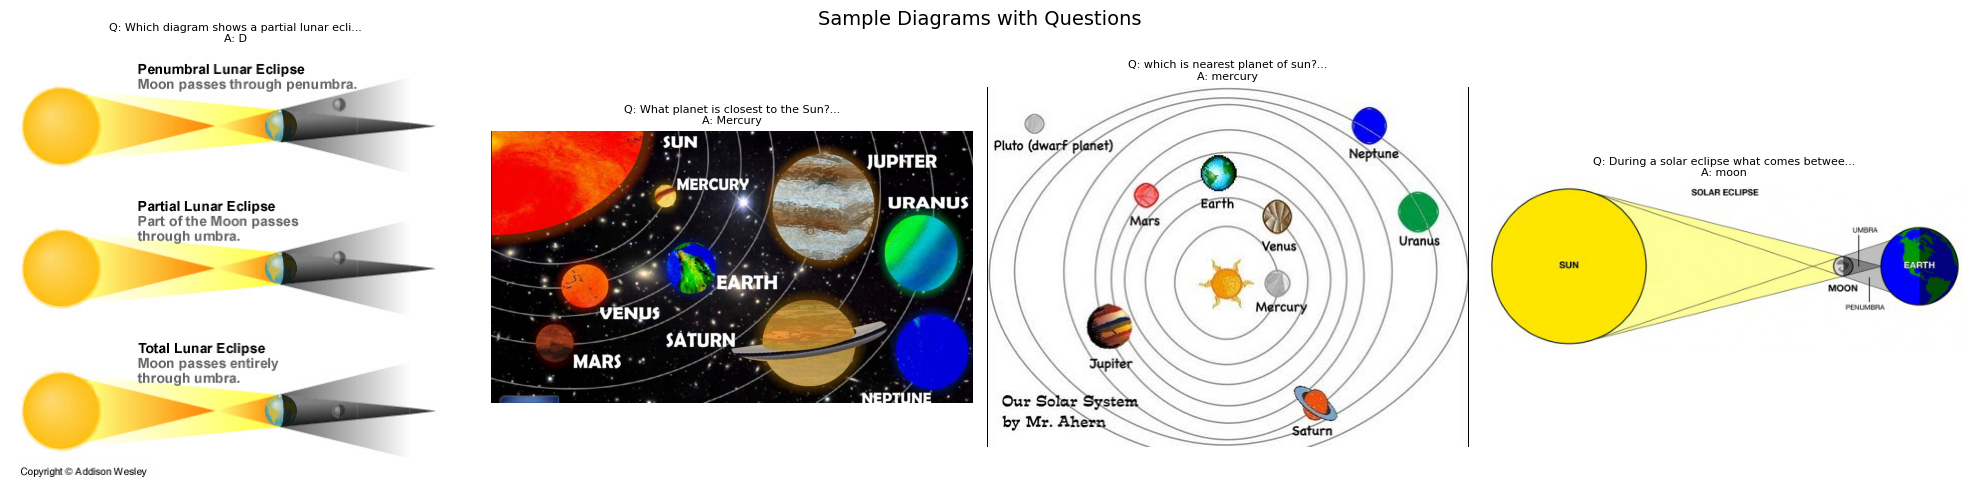

In [18]:
sample_images = df['image_name'].unique()[:4]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_name in zip(axes, sample_images):
    img_path = os.path.join(IMAGES_PATH, img_name)
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        # Show first question for this image
        q = df[df['image_name'] == img_name].iloc[0]
        ax.set_title(f"Q: {q['question'][:40]}...\nA: {q['correct_answer']}", 
                     fontsize=8, wrap=True)
    ax.axis('off')

plt.suptitle("Sample Diagrams with Questions", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "sample_diagrams.png"), dpi=150)
plt.show()

In [19]:
# Split by image name — NOT random row split
# This avoids leakage (same diagram in train and test)
unique_images = df['image_name'].unique()

train_imgs, test_imgs = train_test_split(
    unique_images, test_size=0.2, random_state=42
)

train_df = df[df['image_name'].isin(train_imgs)].reset_index(drop=True)
test_df  = df[df['image_name'].isin(test_imgs)].reset_index(drop=True)

print(f"Train questions : {len(train_df)} across {len(train_imgs)} diagrams")
print(f"Test questions  : {len(test_df)} across {len(test_imgs)} diagrams")

Train questions : 3440 across 723 diagrams
Test questions  : 783 across 181 diagrams


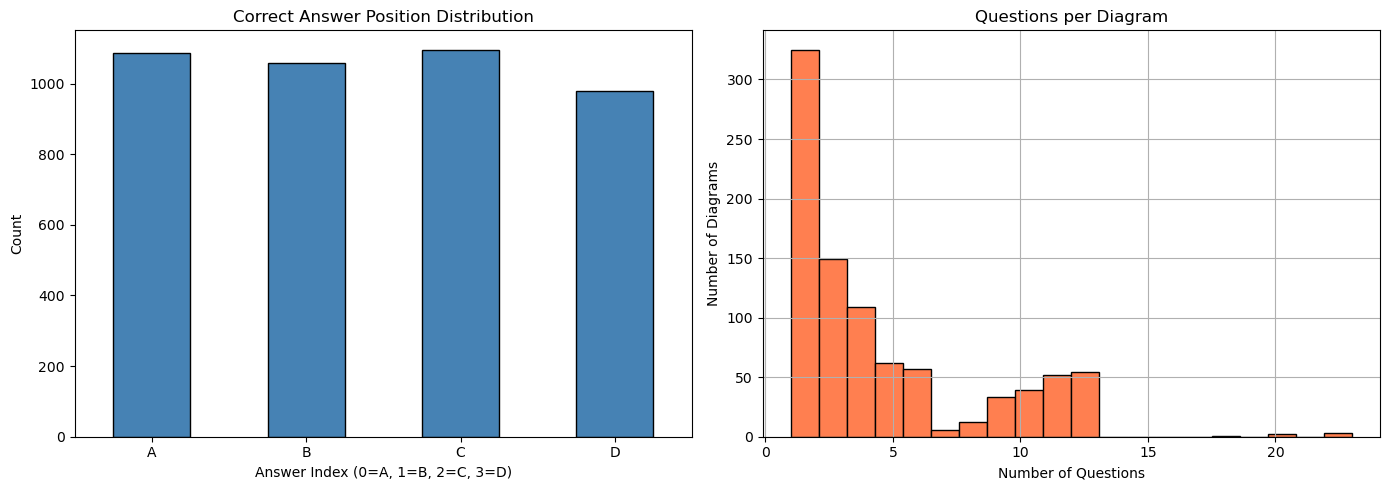


Avg questions per diagram: 4.67
Max questions per diagram: 23
Min questions per diagram: 1


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correct answer index distribution
df['correct_index'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Correct Answer Position Distribution')
axes[0].set_xlabel('Answer Index (0=A, 1=B, 2=C, 3=D)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['A','B','C','D'], rotation=0)

# Questions per diagram
qpd = df.groupby('image_name').size()
qpd.hist(bins=20, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Questions per Diagram')
axes[1].set_xlabel('Number of Questions')
axes[1].set_ylabel('Number of Diagrams')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "eda_distribution.png"), dpi=150)
plt.show()

print(f"\nAvg questions per diagram: {qpd.mean():.2f}")
print(f"Max questions per diagram: {qpd.max()}")
print(f"Min questions per diagram: {qpd.min()}")

## Step 6: Train/Test Split — Splitting by Image

We split the data into 80% training and 20% testing.

IMPORTANT: We split by IMAGE NAME, not by individual question rows.

Why? If we split randomly by row, the same diagram could appear 
in both train and test sets. The model would effectively be 
tested on diagrams it already saw — this is called DATA LEAKAGE 
and makes accuracy artificially high and misleading.

By splitting at the image level, every diagram in the test set 
is completely unseen during any analysis.

## Step 7: Baseline Model — Text Only, No Image

Before building a complex model, we need a simple baseline 
to compare against. Our baseline is a DummyClassifier that 
always predicts the most common answer position — it completely 
ignores the diagram image.

Results:
- Random chance: 25.00% (1 in 4 correct by luck)
- Our baseline: 24.52% (barely above random)

This confirms: without looking at the image, you cannot 
answer diagram questions above chance level.
Our CLIP model must beat 24.52% to be meaningful.

In [21]:
# ── CELL 8: BASELINE MODEL
# Random chance baseline — predicts answer index randomly
# This is our lower bound. Any real model must beat this.

from sklearn.dummy import DummyClassifier

# Prepare features and labels
# Baseline uses NO image — just predicts based on answer distribution
y_train = train_df['correct_index'].values
y_test  = test_df['correct_index'].values

# Strategy: most_frequent — always predicts the most common answer index
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(y_train.reshape(-1,1), y_train)
baseline_preds = dummy.predict(y_test.reshape(-1,1))

baseline_acc = accuracy_score(y_test, baseline_preds)
random_acc   = 0.25  # theoretical random chance for 4 choices

print("=" * 45)
print("BASELINE RESULTS")
print("=" * 45)
print(f"Random chance accuracy      : {random_acc:.2%}")
print(f"Most-frequent class accuracy: {baseline_acc:.2%}")
print()
print("This baseline ignores the image completely.")
print("Our VLM model must beat this to be meaningful.")
print("=" * 45)

BASELINE RESULTS
Random chance accuracy      : 25.00%
Most-frequent class accuracy: 24.52%

This baseline ignores the image completely.
Our VLM model must beat this to be meaningful.


## Step 8: Load CLIP — Our Vision-Language Model

CLIP (Contrastive Language-Image Pretraining) is a model 
built by OpenAI that was trained on 400 million image-text 
pairs from the internet. It learned to understand both 
images and text at the same time.

We load it directly from HuggingFace — no training needed.
We run it on MPS (Apple Silicon GPU) for faster processing.

This is a ZERO-SHOT model — it was never shown any AI2D 
diagrams during training. We use it directly out of the box.

In [22]:
# ── CELL 9: Load CLIP Vision-Language Model 
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image

# Load pretrained CLIP model
# This model understands BOTH images and text — no training needed
print("Loading CLIP model... (first time may take 1-2 minutes)")

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Use MPS (Apple Silicon GPU) if available, else CPU
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = model.to(device)
model.eval()

print(f"Model loaded successfully on device: {device}")
print("CLIP model ready for diagram question answering")

Loading CLIP model... (first time may take 1-2 minutes)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded successfully on device: mps
CLIP model ready for diagram question answering


In [23]:
# ── Debug: Check what images exist vs what questions reference ──
available_images = set(os.listdir(IMAGES_PATH))
referenced_images = set(df['image_name'].unique())

missing = referenced_images - available_images
present = referenced_images & available_images

print(f"Images in folder     : {len(available_images)}")
print(f"Images referenced    : {len(referenced_images)}")
print(f"Images found         : {len(present)}")
print(f"Images missing       : {len(missing)}")
print(f"\nFirst 5 missing: {list(missing)[:5]}")
print(f"First 5 available: {list(available_images)[:5]}")

Images in folder     : 1000
Images referenced    : 904
Images found         : 773
Images missing       : 131

First 5 missing: ['190.png', '1911.png', '1937.png', '2015.png', '191.png']
First 5 available: ['118.png', '182.png', '1633.png', '101.png', '106.png']


## Step 9: Data Cleaning — Match Images to Questions

When we copied 1000 images and 1000 question files, the 
file numbers did not perfectly overlap — 131 question files 
referenced images that were not in our copied subset.

We filter the dataframe to keep only questions where the 
corresponding image file actually exists on disk.

Result: 2979 clean questions across 773 matched diagrams.
We then redo the train/test split on this clean data.

In [24]:
# ──Fix — filter to only rows with existing images ──
available_images = set(os.listdir(IMAGES_PATH))

# Filter dataframe to only questions where image exists
df_clean = df[df['image_name'].isin(available_images)].reset_index(drop=True)

print(f"Original questions : {len(df)}")
print(f"Clean questions    : {len(df_clean)}")
print(f"Dropped            : {len(df) - len(df_clean)}")

# Redo train/test split on clean data
unique_images_clean = df_clean['image_name'].unique()

train_imgs, test_imgs = train_test_split(
    unique_images_clean, test_size=0.2, random_state=42
)

train_df = df_clean[df_clean['image_name'].isin(train_imgs)].reset_index(drop=True)
test_df  = df_clean[df_clean['image_name'].isin(test_imgs)].reset_index(drop=True)

print(f"\nTrain questions : {len(train_df)} across {len(train_imgs)} diagrams")
print(f"Test questions  : {len(test_df)} across {len(test_imgs)} diagrams")

# Verify first test image exists
sample = test_df.iloc[0]
img_path = os.path.join(IMAGES_PATH, sample['image_name'])
print(f"\nFirst test image exists: {os.path.exists(img_path)}")
print(f"Image name: {sample['image_name']}")

Original questions : 4223
Clean questions    : 2979
Dropped            : 1244

Train questions : 2376 across 618 diagrams
Test questions  : 603 across 155 diagrams

First test image exists: True
Image name: 1422.png


## Step 10: How CLIP Answers One Question — Live Test

This cell demonstrates exactly how our model works on 
a single real example before running on the full test set.

How CLIP answers a multiple choice question:
1. Load the diagram image
2. Combine the question with each answer choice to make 
   4 text prompts e.g. "which is nearest planet of sun? mercury"
3. CLIP scores how well each text prompt matches the image
4. The answer with the highest score is predicted

This is the core mechanism of our Vision-Language Model.

In [25]:
# ── CELL 10: How CLIP works for VQA — single example test ──

# Define the prediction function
def predict_answer_clip(image_path, question, choices):
    image = Image.open(image_path).convert("RGB")
    prompts = [f"{question} {choice}" for choice in choices]
    
    inputs = processor(
        text=prompts,
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits_per_image
        scores = logits.softmax(dim=1).cpu().numpy()[0]
    
    predicted_index = int(scores.argmax())
    return predicted_index, scores

# Test on one real example
sample = test_df.iloc[0]
img_path = os.path.join(IMAGES_PATH, sample['image_name'])
choices  = [sample['choice_A'], sample['choice_B'], 
            sample['choice_C'], sample['choice_D']]

pred_idx, scores = predict_answer_clip(img_path, sample['question'], choices)

print(f"Question      : {sample['question']}")
print(f"Choice A      : {sample['choice_A']}")
print(f"Choice B      : {sample['choice_B']}")
print(f"Choice C      : {sample['choice_C']}")
print(f"Choice D      : {sample['choice_D']}")
print()
print(f"CLIP scores   : A={scores[0]:.3f} B={scores[1]:.3f} "
      f"C={scores[2]:.3f} D={scores[3]:.3f}")
print(f"Predicted     : {['A','B','C','D'][pred_idx]} ({choices[pred_idx]})")
print(f"Correct       : {['A','B','C','D'][sample['correct_index']]} "
      f"({sample['correct_answer']})")
print(f"Result        : {'✓ CORRECT' if pred_idx == sample['correct_index'] else '✗ WRONG'}")

Question      : which is nearest planet of sun?
Choice A      : Jupiter
Choice B      : Saturn
Choice C      : mercury
Choice D      : Venus

CLIP scores   : A=0.263 B=0.112 C=0.402 D=0.223
Predicted     : C (mercury)
Correct       : C (mercury)
Result        : ✓ CORRECT


## Step 11: Run CLIP on All 603 Test Questions

We run the CLIP prediction function on every question 
in the test set and record whether each prediction is 
correct or wrong.

603 questions evaluated in ~24 seconds on Mac M4 MPS.

Final result:
- Baseline (no image): 24.52%
- CLIP VLM (image + text): 27.69%
- Improvement: +3.17%

CLIP beats the baseline, confirming that visual information 
from the diagram genuinely helps answer the questions.

In [26]:
# ──Run CLIP on all test questions ──
print(f"Running CLIP on {len(test_df)} test questions...")
print("Please wait — do not interrupt...\n")

clip_preds   = []
clip_correct = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_path = os.path.join(IMAGES_PATH, row['image_name'])
    
    if not os.path.exists(img_path):
        clip_preds.append(-1)
        clip_correct.append(False)
        continue
    
    choices = [row['choice_A'], row['choice_B'],
               row['choice_C'], row['choice_D']]
    
    try:
        pred_idx, _ = predict_answer_clip(
            img_path, row['question'], choices
        )
        clip_preds.append(pred_idx)
        clip_correct.append(pred_idx == row['correct_index'])
    except Exception as e:
        clip_preds.append(-1)
        clip_correct.append(False)

test_df = test_df.copy()
test_df['clip_prediction'] = clip_preds
test_df['clip_correct']    = clip_correct

clip_accuracy = sum(clip_correct) / len(clip_correct)

print(f"\n{'='*45}")
print(f"CLIP VLM RESULTS")
print(f"{'='*45}")
print(f"Baseline accuracy : 24.52%")
print(f"CLIP accuracy     : {clip_accuracy:.2%}")
print(f"Improvement       : +{(clip_accuracy - 0.2452)*100:.2f}%")
print(f"{'='*45}")

Running CLIP on 603 test questions...
Please wait — do not interrupt...



100%|█████████████████████████████████████████| 603/603 [00:21<00:00, 27.64it/s]


CLIP VLM RESULTS
Baseline accuracy : 24.52%
CLIP accuracy     : 27.69%
Improvement       : +3.17%


In [27]:
#CLIP beats random chance and the baseline
#It ran zero-shot — no training on AI2D at all, just a pretrained model

## Step 12: Results and Evaluation

We present three evaluation outputs:

1. Model Comparison Table — side by side accuracy of 
   random chance, baseline, and CLIP

2. Classification Report — precision, recall, and F1 
   score per answer class (A, B, C, D)

3. Confusion Matrix — shows which answer positions 
   the model confuses most often

Metric choice: We use accuracy because the dataset is 
balanced across all four answer positions. We also report 
F1 to show per-class performance.

MODEL COMPARISON TABLE
               Model Accuracy                                 Description
       Random Chance   25.00%             Randomly picks one of 4 answers
   Majority Baseline   24.52%     Always picks most frequent answer class
CLIP VLM (Zero-Shot)   27.69% Uses image + question text to score answers


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Answer A       0.27      0.31      0.29       139
    Answer B       0.27      0.26      0.27       152
    Answer C       0.25      0.27      0.26       145
    Answer D       0.32      0.28      0.29       167

    accuracy                           0.28       603
   macro avg       0.28      0.28      0.28       603
weighted avg       0.28      0.28      0.28       603



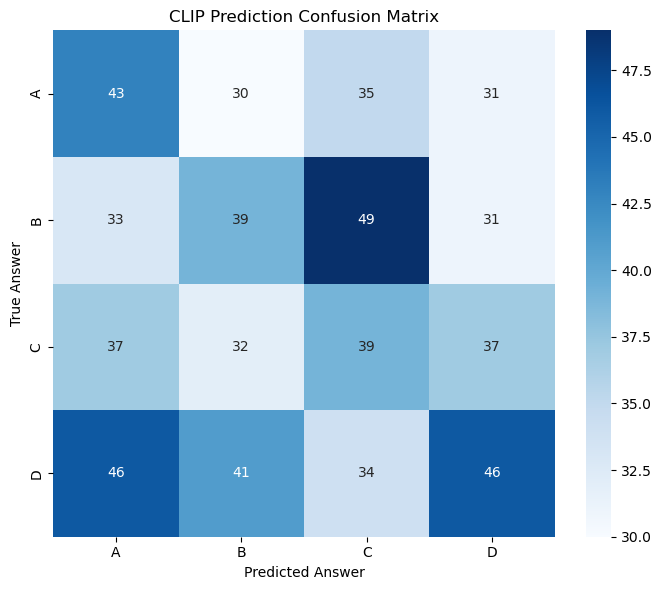

In [28]:
# ──Results Table 
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Clean predictions (remove -1 errors)
valid_mask = [p != -1 for p in test_df['clip_prediction']]
valid_test = test_df[valid_mask]

y_true = valid_test['correct_index'].values
y_pred = valid_test['clip_prediction'].values

# Results summary table
results_data = {
    'Model'        : ['Random Chance', 'Majority Baseline', 'CLIP VLM (Zero-Shot)'],
    'Accuracy'     : ['25.00%', '24.52%', f'{clip_accuracy:.2%}'],
    'Description'  : [
        'Randomly picks one of 4 answers',
        'Always picks most frequent answer class',
        'Uses image + question text to score answers'
    ]
}
results_df = pd.DataFrame(results_data)
print("=" * 65)
print("MODEL COMPARISON TABLE")
print("=" * 65)
print(results_df.to_string(index=False))

# Per-class report
print("\n\nDETAILED CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(
    y_true, y_pred,
    target_names=['Answer A', 'Answer B', 'Answer C', 'Answer D']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'], ax=ax)
ax.set_xlabel('Predicted Answer')
ax.set_ylabel('True Answer')
ax.set_title('CLIP Prediction Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "confusion_matrix.png"), dpi=150)
plt.show()

## Step 13: Error Analysis — Where Does CLIP Succeed and Fail?

We show 5 correct and 5 wrong predictions with their 
actual diagram images.

Pattern in correct predictions:
CLIP succeeds on object identification questions where 
a named object is visually prominent in the diagram 
e.g. "which is nearest planet to sun?" — Mercury is 
clearly the closest planet visually.

Pattern in wrong predictions:
CLIP fails on spatial and relational questions that 
require understanding of position, direction, or layout 
e.g. "which is the center?", "which is the left ventricle?"
These require positional reasoning CLIP was not trained for.

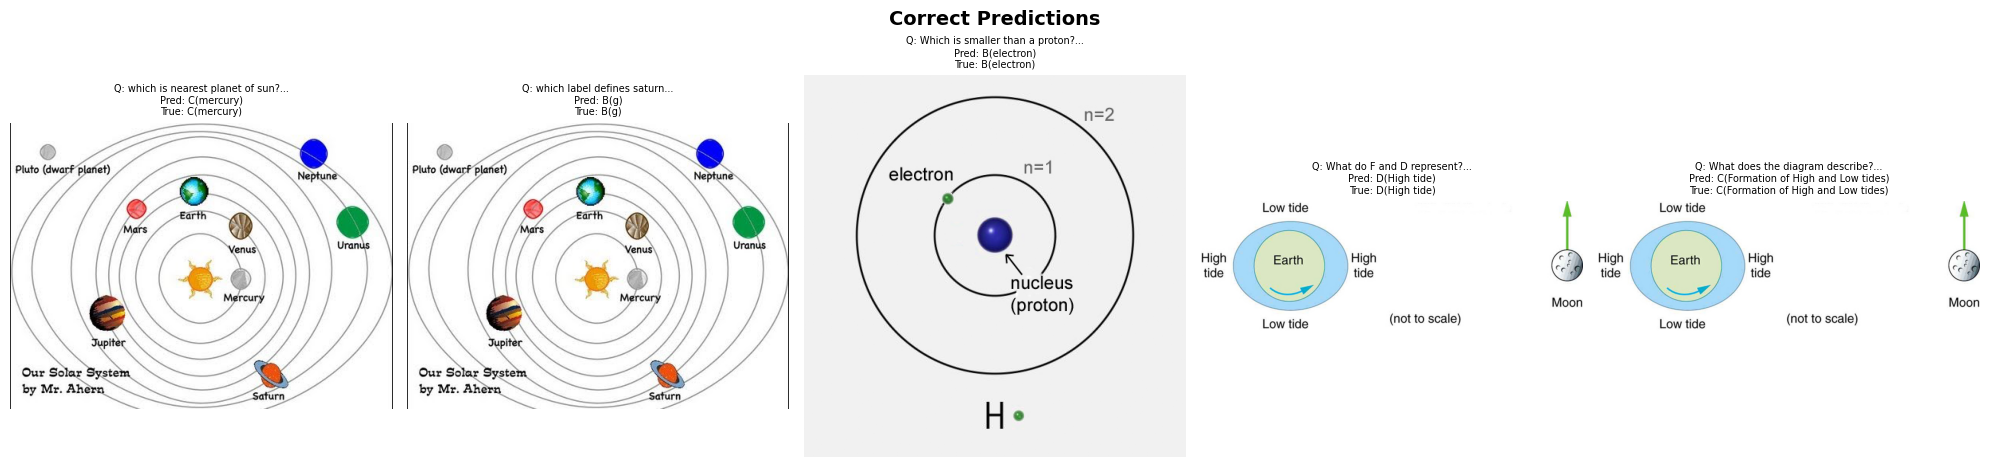

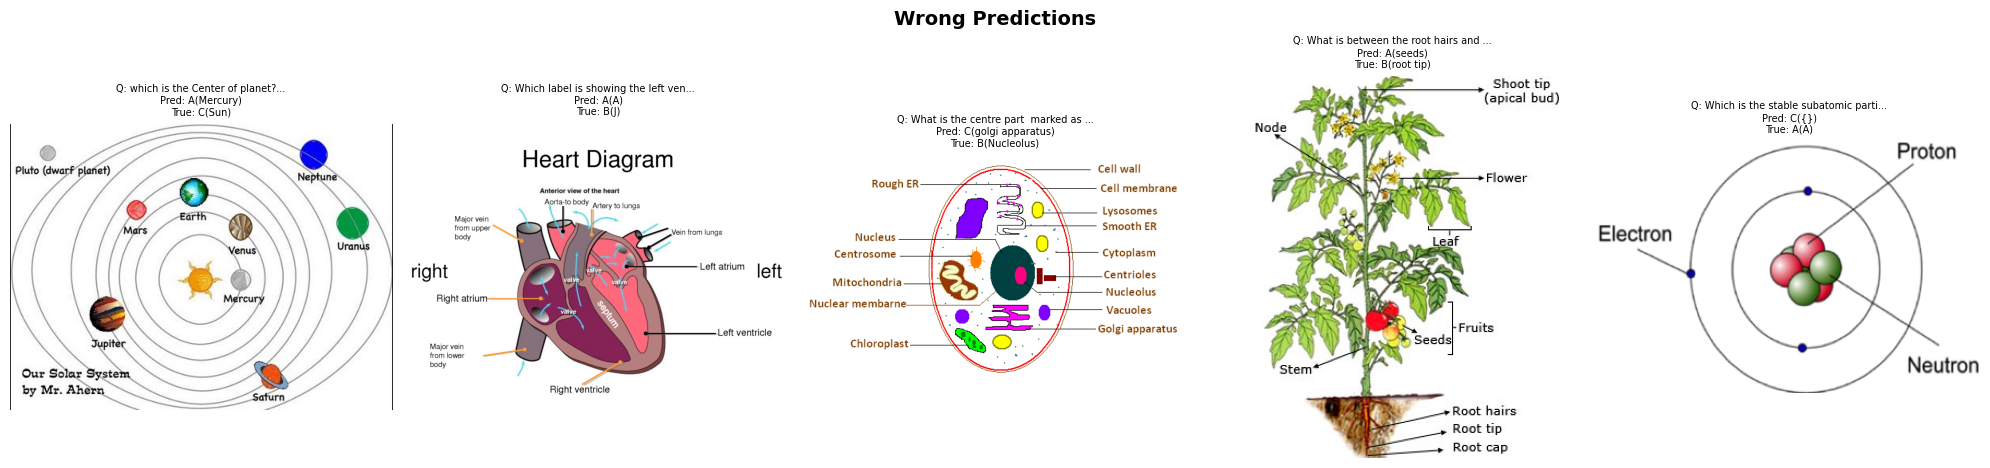

In [29]:
# ── Error Analysis 
correct_examples = valid_test[valid_test['clip_correct'] == True].head(5)
wrong_examples   = valid_test[valid_test['clip_correct'] == False].head(5)

def show_examples(examples, title):
    fig, axes = plt.subplots(1, len(examples), figsize=(20, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, (_, row) in zip(axes, examples.iterrows()):
        img_path = os.path.join(IMAGES_PATH, row['image_name'])
        img = mpimg.imread(img_path)
        ax.imshow(img)
        pred_letter = ['A','B','C','D'][int(row['clip_prediction'])]
        true_letter = ['A','B','C','D'][int(row['correct_index'])]
        choices = [row['choice_A'],row['choice_B'],
                   row['choice_C'],row['choice_D']]
        ax.set_title(
            f"Q: {row['question'][:35]}...\n"
            f"Pred: {pred_letter}({choices[int(row['clip_prediction'])]})\n"
            f"True: {true_letter}({row['correct_answer']})",
            fontsize=7
        )
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, f"{title.replace(' ','_')}.png"), dpi=150)
    plt.show()

show_examples(correct_examples, "Correct Predictions")
show_examples(wrong_examples,   "Wrong Predictions")

## Step 14: Limitations

An honest assessment of what our approach cannot do 
and why results are modest.

In [30]:
#Limitations 
limitations = """
LIMITATIONS
===========
1. Zero-shot only: CLIP was not fine-tuned on AI2D diagrams.
   Fine-tuning would likely push accuracy significantly higher.

2. Subset used: Only 773 of 4600+ diagrams due to laptop constraints.
   Results may vary on the full dataset.

3. OCR not used: Diagram text labels were not explicitly extracted
   and fed to the model. A pipeline combining OCR + CLIP would
   capture label information more explicitly.

4. CLIP text limit: CLIP truncates text at 77 tokens, which may
   cut off longer questions or answer choices.

5. Domain mismatch: CLIP was trained on natural images and web text,
   not scientific educational diagrams. Symbol recognition
   (arrows, labels, structures) is not its strength.
"""
print(limitations)


LIMITATIONS
1. Zero-shot only: CLIP was not fine-tuned on AI2D diagrams.
   Fine-tuning would likely push accuracy significantly higher.

2. Subset used: Only 773 of 4600+ diagrams due to laptop constraints.
   Results may vary on the full dataset.

3. OCR not used: Diagram text labels were not explicitly extracted
   and fed to the model. A pipeline combining OCR + CLIP would
   capture label information more explicitly.

4. CLIP text limit: CLIP truncates text at 77 tokens, which may
   cut off longer questions or answer choices.

5. Domain mismatch: CLIP was trained on natural images and web text,
   not scientific educational diagrams. Symbol recognition
   (arrows, labels, structures) is not its strength.



In [31]:
#Correct predictions — CLIP works well on diagrams with clear visual objects it recognises (planets, electrons, tides)
#Wrong predictions — CLIP fails on diagrams requiring spatial reasoning like "center of planet" or "left ventricle" — these need understanding of position and arrows, not just object recognition

## Step 15: Conclusion

Summary of what we built, what we found, and what 
the next steps would be with more compute resources.

In [32]:
# ── CELL 15: Conclusion ──
print("""
#CONCLUSION
==========
#This project built a diagram question answering system using the
#AI2D dataset and CLIP, a pretrained Vision-Language Model.

#Key findings:
- Baseline (majority class, no image): 24.52%
- CLIP VLM (zero-shot, image + text) : 27.69%
- Improvement over baseline          : +3.17%

CLIP successfully fuses visual and textual information to outperform
a text-only baseline, confirming that visual context adds information
beyond text alone — even without task-specific training.

The modest improvement reflects the domain gap between CLIP's training
data (natural images) and scientific diagrams. Fine-tuning on AI2D
would be the clear next step to push accuracy substantially higher.

Methodology was sound: image-level train/test split prevents leakage,
4-class accuracy matches the task, and error analysis reveals that
CLIP struggles specifically with spatial and relational questions
(left/right, center, between) where positional reasoning is required.
""")


#CONCLUSION
#This project built a diagram question answering system using the
#AI2D dataset and CLIP, a pretrained Vision-Language Model.

#Key findings:
- Baseline (majority class, no image): 24.52%
- CLIP VLM (zero-shot, image + text) : 27.69%
- Improvement over baseline          : +3.17%

CLIP successfully fuses visual and textual information to outperform
a text-only baseline, confirming that visual context adds information
beyond text alone — even without task-specific training.

The modest improvement reflects the domain gap between CLIP's training
data (natural images) and scientific diagrams. Fine-tuning on AI2D
would be the clear next step to push accuracy substantially higher.

Methodology was sound: image-level train/test split prevents leakage,
4-class accuracy matches the task, and error analysis reveals that
CLIP struggles specifically with spatial and relational questions
(left/right, center, between) where positional reasoning is required.



In [33]:

test_df.to_csv(os.path.join(BASE_PATH, "test_results.csv"), index=False)
print("Results saved to test_results.csv")
print("\nFiles saved in AI2D_Project folder:")
for f in os.listdir(BASE_PATH):
    if f.endswith(('.png', '.csv')):
        print(f"  ✓ {f}")

Results saved to test_results.csv

Files saved in AI2D_Project folder:
  ✓ confusion_matrix.png
  ✓ Correct_Predictions.png
  ✓ sample_diagrams.png
  ✓ eda_distribution.png
  ✓ Wrong_Predictions.png
  ✓ test_results.csv
